## 프로젝트 1번 당뇨병 수치 

In [55]:
## 데이터 가져오기

from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

## 모델에 입력할 데이터 X 준비하기

import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

## 모델에 예측할 데이터 y 준비하기

y = np.array(df_y)

print(type(y), y.dtype)

## train 데이터와 test 데이터로 분리하기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

## 모델 가중치
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

## 모델 함수
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

## 손실 함수
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

## grad 함수
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

## 하이퍼 파라미터
LEARNING_RATE = 0.05
losses = []

<class 'numpy.ndarray'> float64
<class 'numpy.ndarray'> float64
(353, 10) (353,)
(89, 10) (89,)
10


Iteration 100 : Loss 3085.3759
Iteration 200 : Loss 3076.9755
Iteration 300 : Loss 3068.9925
Iteration 400 : Loss 3061.4026
Iteration 500 : Loss 3054.1836
Iteration 600 : Loss 3047.3147
Iteration 700 : Loss 3040.7765
Iteration 800 : Loss 3034.5512
Iteration 900 : Loss 3028.6220
Iteration 1000 : Loss 3022.9732
Iteration 1100 : Loss 3017.5901
Iteration 1200 : Loss 3012.4590
Iteration 1300 : Loss 3007.5669
Iteration 1400 : Loss 3002.9017
Iteration 1500 : Loss 2998.4519
Iteration 1600 : Loss 2994.2067
Iteration 1700 : Loss 2990.1560
Iteration 1800 : Loss 2986.2900
Iteration 1900 : Loss 2982.5998
Iteration 2000 : Loss 2979.0767
Iteration 2100 : Loss 2975.7125
Iteration 2200 : Loss 2972.4996
Iteration 2300 : Loss 2969.4307
Iteration 2400 : Loss 2966.4988
Iteration 2500 : Loss 2963.6974
Iteration 2600 : Loss 2961.0203
Iteration 2700 : Loss 2958.4615
Iteration 2800 : Loss 2956.0155
Iteration 2900 : Loss 2953.6769
Iteration 3000 : Loss 2951.4407
Iteration 3100 : Loss 2949.3021
Iteration 3200 : 

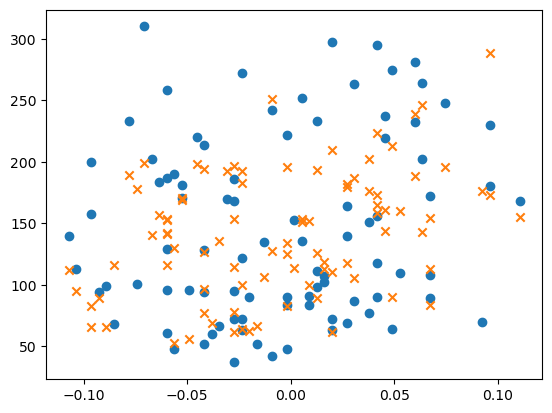

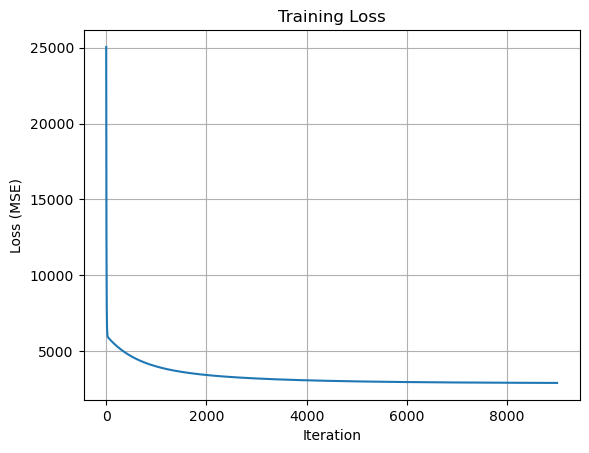

964 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [57]:
%%timeit -n 1 -r 1          ## 모델 학습하기
global W, b



for i in range(1, 5001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

## test 데이터에 대한 성능 확인하기
mse = loss(X_test, W, b, y_test)
prediction = model(X_test, W, b)
print(f"{mse}")

## 정답 데이터와 예측한 데이터 시각화하기
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test, marker='o')    ## 정닶은 o
plt.scatter(X_test[:, 0], prediction, marker='x') ## 예측값 x
plt.show()

plt.plot(losses)         ## Loss 그래프 그리기
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.grid()

plt.show()

## 프로젝트 2번 자전거 

In [59]:
## 데이터 가져오기

import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [60]:
## datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기

train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

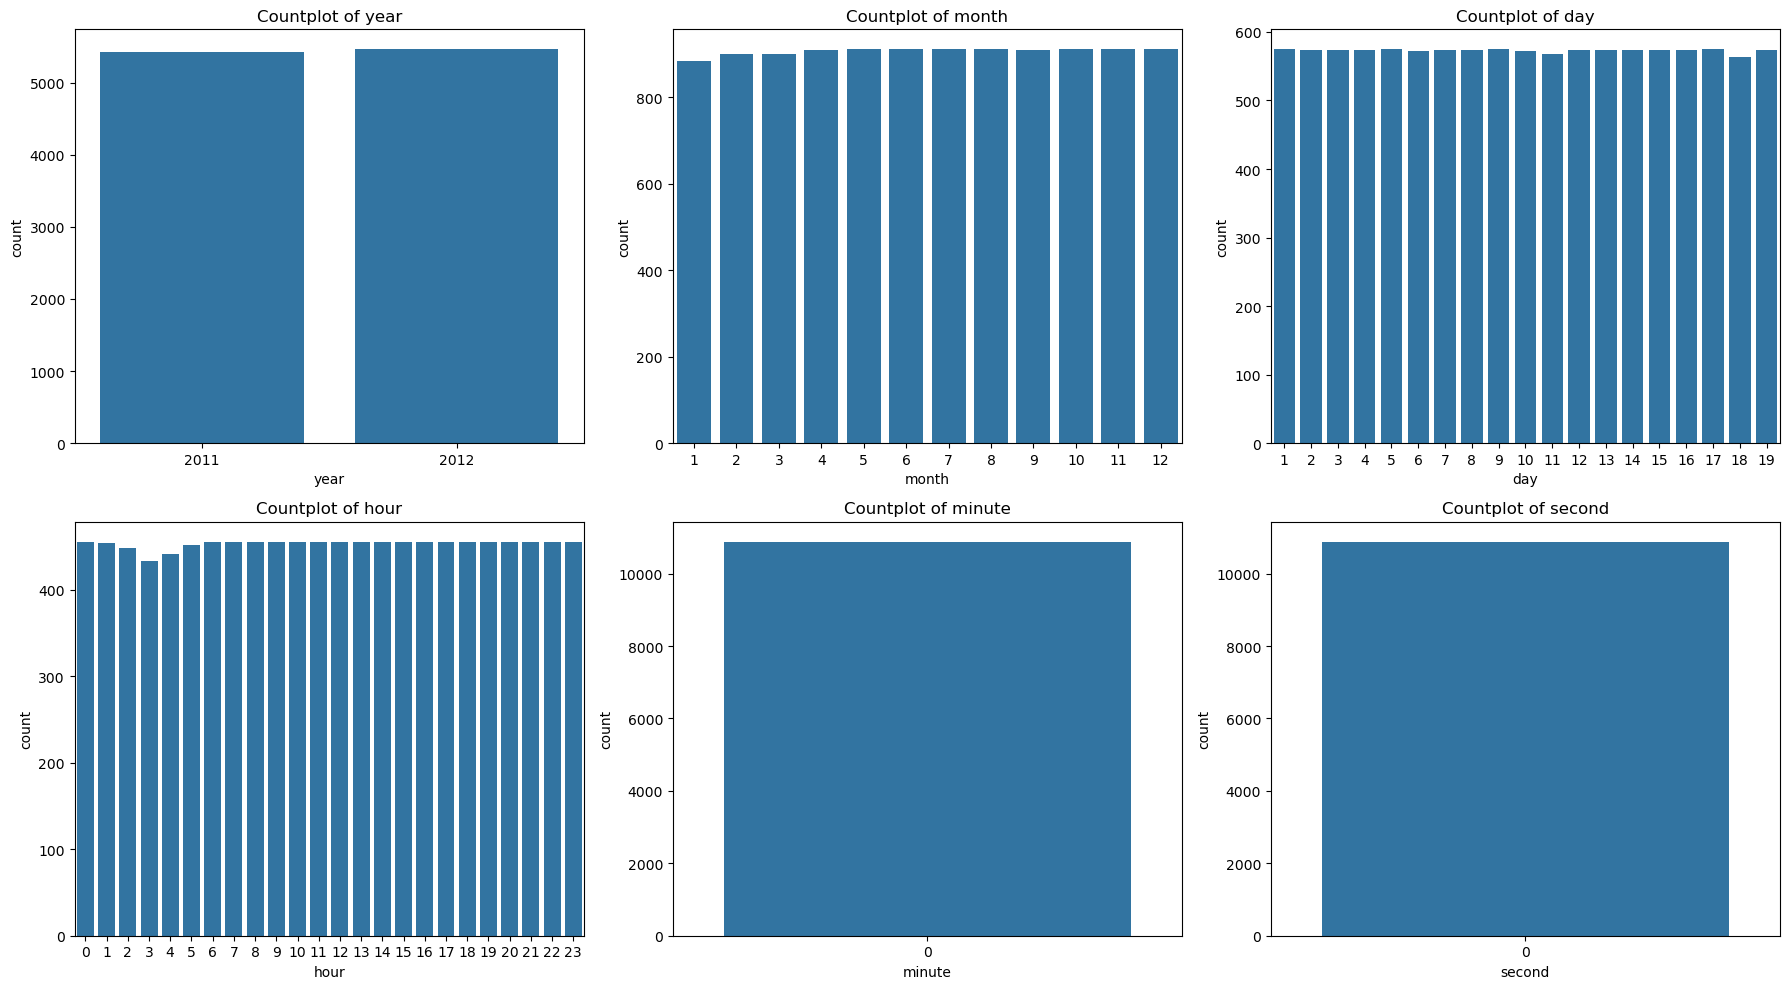

In [63]:
## year, month, day, hour, minute, second 데이터 개수 시각화하기
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

In [64]:
## X, y 컬럼 선택 및 train/test 데이터 분리
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
## LinearRegression 모델 학습
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [66]:
## 학습된 모델로 X_test에 대한 예측값 출력 및 손실함수값 계산
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435438
RMSE: 141.2865946027274


In [ ]:
##  x축은 temp 또는 humidity로, y축은 count로 예측 결과 시각화하기
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()